In [1]:
import polars as pl
import os 
import requests
import matplotlib.pyplot as plt
from datetime import datetime, timezone

QUESTDB_ENDPOINT = "https://timeseriesdbfrancesco.dev.rd.areasciencepark.it"
def get_table_data(filename, query: str) -> pl.DataFrame:
    filename = str(filename)
    if os.path.exists(filename):
        return pl.read_ipc(filename)
    response = requests.get(f"{QUESTDB_ENDPOINT}/exec", params={"query": query},
                            verify=False, timeout=60)
    response.raise_for_status()
    payload = response.json()
    df = pl.DataFrame(payload["dataset"], schema=[c["name"] for c in payload["columns"]],
                      orient="row")
    if "timestamp" in df.columns:
        df = df.with_columns(
            pl.col("timestamp").str.strptime(pl.Datetime, "%Y-%m-%dT%H:%M:%S%.fZ", strict=False))
    #df.write_ipc(filename)
    return df

In [2]:
LCST_STATS_PATH = lambda model_name, gen_toks : f"./logs/stats_{model_name}_t{gen_toks}__stats_history.csv"

GEN_TOKENS = [
    250,
    500,
    1000,
    1500,
    3000,
    5000,
    8000
]
GEN_TOKENS = [str(n) for n in GEN_TOKENS]

MODELS = [
    "Qwen3.8",
    "Qwen3.6"
]

RESULTS = {}
for m in MODELS: 
    RESULTS[m] = {}
    for toks in GEN_TOKENS:
        RESULTS[m][toks] = {}

LCST = {}
# Read stats history for all models
for m in MODELS:
    LCST[m] = {}
    for toks in GEN_TOKENS:
        LCST[m][toks] = pl.read_csv(LCST_STATS_PATH(model_name=m, gen_toks=toks))

for m in MODELS:
    for toks in GEN_TOKENS:
        LCST[m][toks] = LCST[m][toks].with_columns(
            pl.from_epoch(pl.col("Timestamp"), time_unit="s").alias("Datetime")
        )


In [17]:
obsBegin = min( LCST[m][toks]["Timestamp"].min() for m in MODELS for toks in GEN_TOKENS )
obsEnd = max( LCST[m][toks]["Timestamp"].min() for m in MODELS for toks in GEN_TOKENS )

def ts_to_questdb_dt_format(ts):
    ts = str(ts).replace(" ", "T") + "Z"
    return ts
    

#"ipmi_power" : f"""
#SELECT timestamp, psu_id, value, unit
#FROM ipmi_power
#WHERE unit='W' AND '{ts_to_questdb_dt_format(obsBegin)}' < timestamp AND timestamp < '{ts_to_questdb_dt_format(obsEnd)}' AND psu_id=0
#""",
QUERIES = {
"nvidia_smi" : f"""
    SELECT timestamp, index, power_draw, utilization_memory, temperature_gpu, utilization_gpu
    FROM nvidia_smi
    WHERE '{ts_to_questdb_dt_format(obsBegin)}' < timestamp AND timestamp < '{ts_to_questdb_dt_format(obsEnd)}'
    """
}

In [21]:
DB = {}
for q in QUERIES: 
    DB[q] = get_table_data("",q)
    DB[q] = DB[q].rename({"timestamp": "Datetime"})
    DB[q] = DB[q].with_columns(
    (pl.col("Datetime").dt.timestamp("us") // 1e6).alias("Timestamp")
)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/urllib3/connectionpool.py:1129: InsecureRequestWarning: Unverified HTTPS request is being made to host 'timeseriesdbfrancesco.dev.rd.areasciencepark.it'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


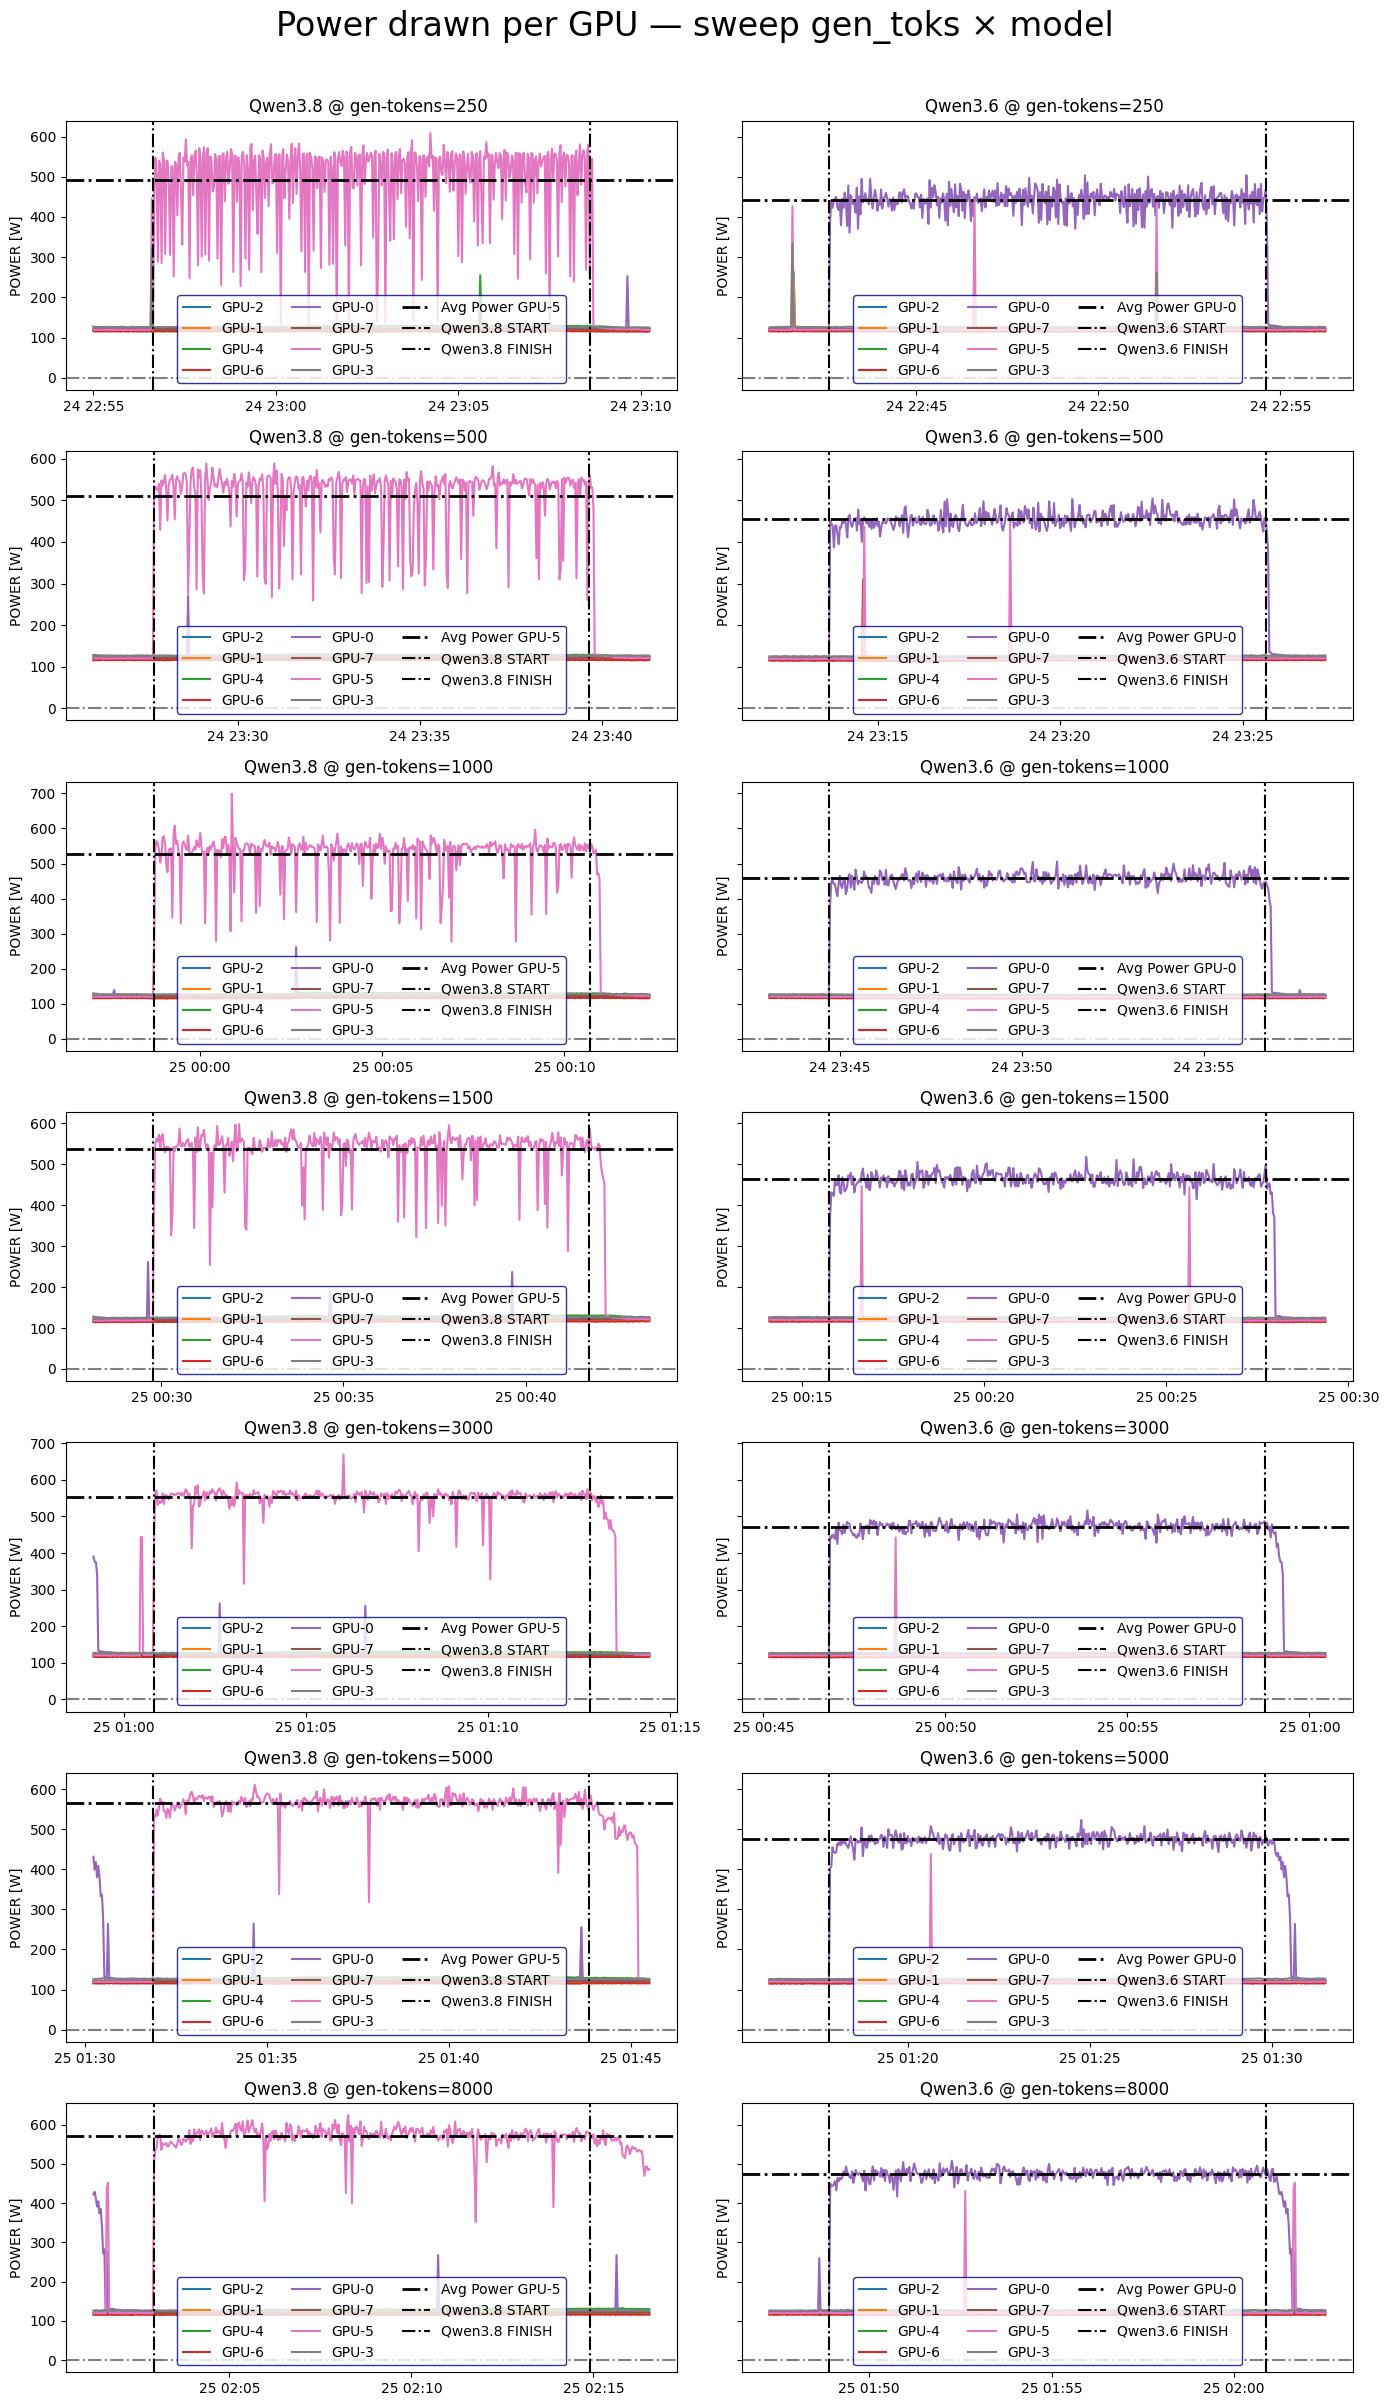

In [50]:
# GPU's are indexed by 'index'
df = DB["nvidia_smi"]

# --- setup grid ---
toks_list = sorted([int(x) for x in LCST[MODELS[0]].keys()])          # chiavi gen_toks (stesse per tutti)
toks_list = [str(x) for x in toks_list]
n_rows, n_cols = len(toks_list), len(MODELS)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(14, 3.5 * n_rows),
                         sharex=False,
                         sharey="row")

# flatten axes se n_rows == 1 (altrimenti 2D array)
if n_rows == 1:
    axes = [axes]


# vediamo il primo processo:
for r, toks in enumerate(toks_list):
    for c,m in enumerate(MODELS):

        ax = axes[r][c] if n_rows > 1 else axes[c]
        proc = LCST[m][toks]
        start, finish = min(proc["Timestamp"]), max(proc["Timestamp"])
        delta = 100 # Adding some pre and post process power usage data
        measures = df.filter(
            pl.col("Timestamp").is_between(start - delta, finish + delta, closed="none")
        )

        max_avg_power = -1          # Tracking the max usage of the gpu
        for gpu_index in set(measures["index"]):
            subm = measures.filter(pl.col("index") == gpu_index)
            ax.plot(subm["Datetime"], subm["power_draw"], label=f"GPU-{gpu_index}")
            # Calculate mean power draw DURING BENCHMARK ONLY
            subm_bench = subm.filter(
                pl.col("Timestamp").is_between(start, finish, closed="none")
            )
            usage = subm_bench["power_draw"].mean()
            if usage > max_avg_power:
                RESULTS[m][toks]["index_GPU"] = gpu_index
                max_avg_power = usage
        RESULTS[m][toks]["avg_power_at_GPU"] = max_avg_power

        ax.axhline(0, color="gray", ls="-.")
        ax.axhline(max_avg_power, ls="-.", lw=2, color="black", label=f"Avg Power GPU-{RESULTS[m][toks]["index_GPU"]}")
        # plotting start and finish times of the benchmark
        ax.axvline(datetime.fromtimestamp(start, timezone.utc), label=f"{m} START", color='black', ls="-.")
        ax.axvline(datetime.fromtimestamp(finish, timezone.utc), label=f"{m} FINISH", color='black', ls="-.")
        ax.set_ylabel(f"POWER [W]") # TODO: confirm it is in Watts
        ax.set_title(f"{m} @ gen-tokens={toks} ")
        # TODO: sort legend
        #RMME--ax.legend(loc="lower center", ncols=3, fontsize="medium", edgecolor='navy')
        ax.legend(fontsize="medium", loc="lower center", ncols=3, edgecolor="navy")

plt.suptitle("Power drawn per GPU — sweep gen_toks × model", fontsize=24)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


Tokens per second analysis

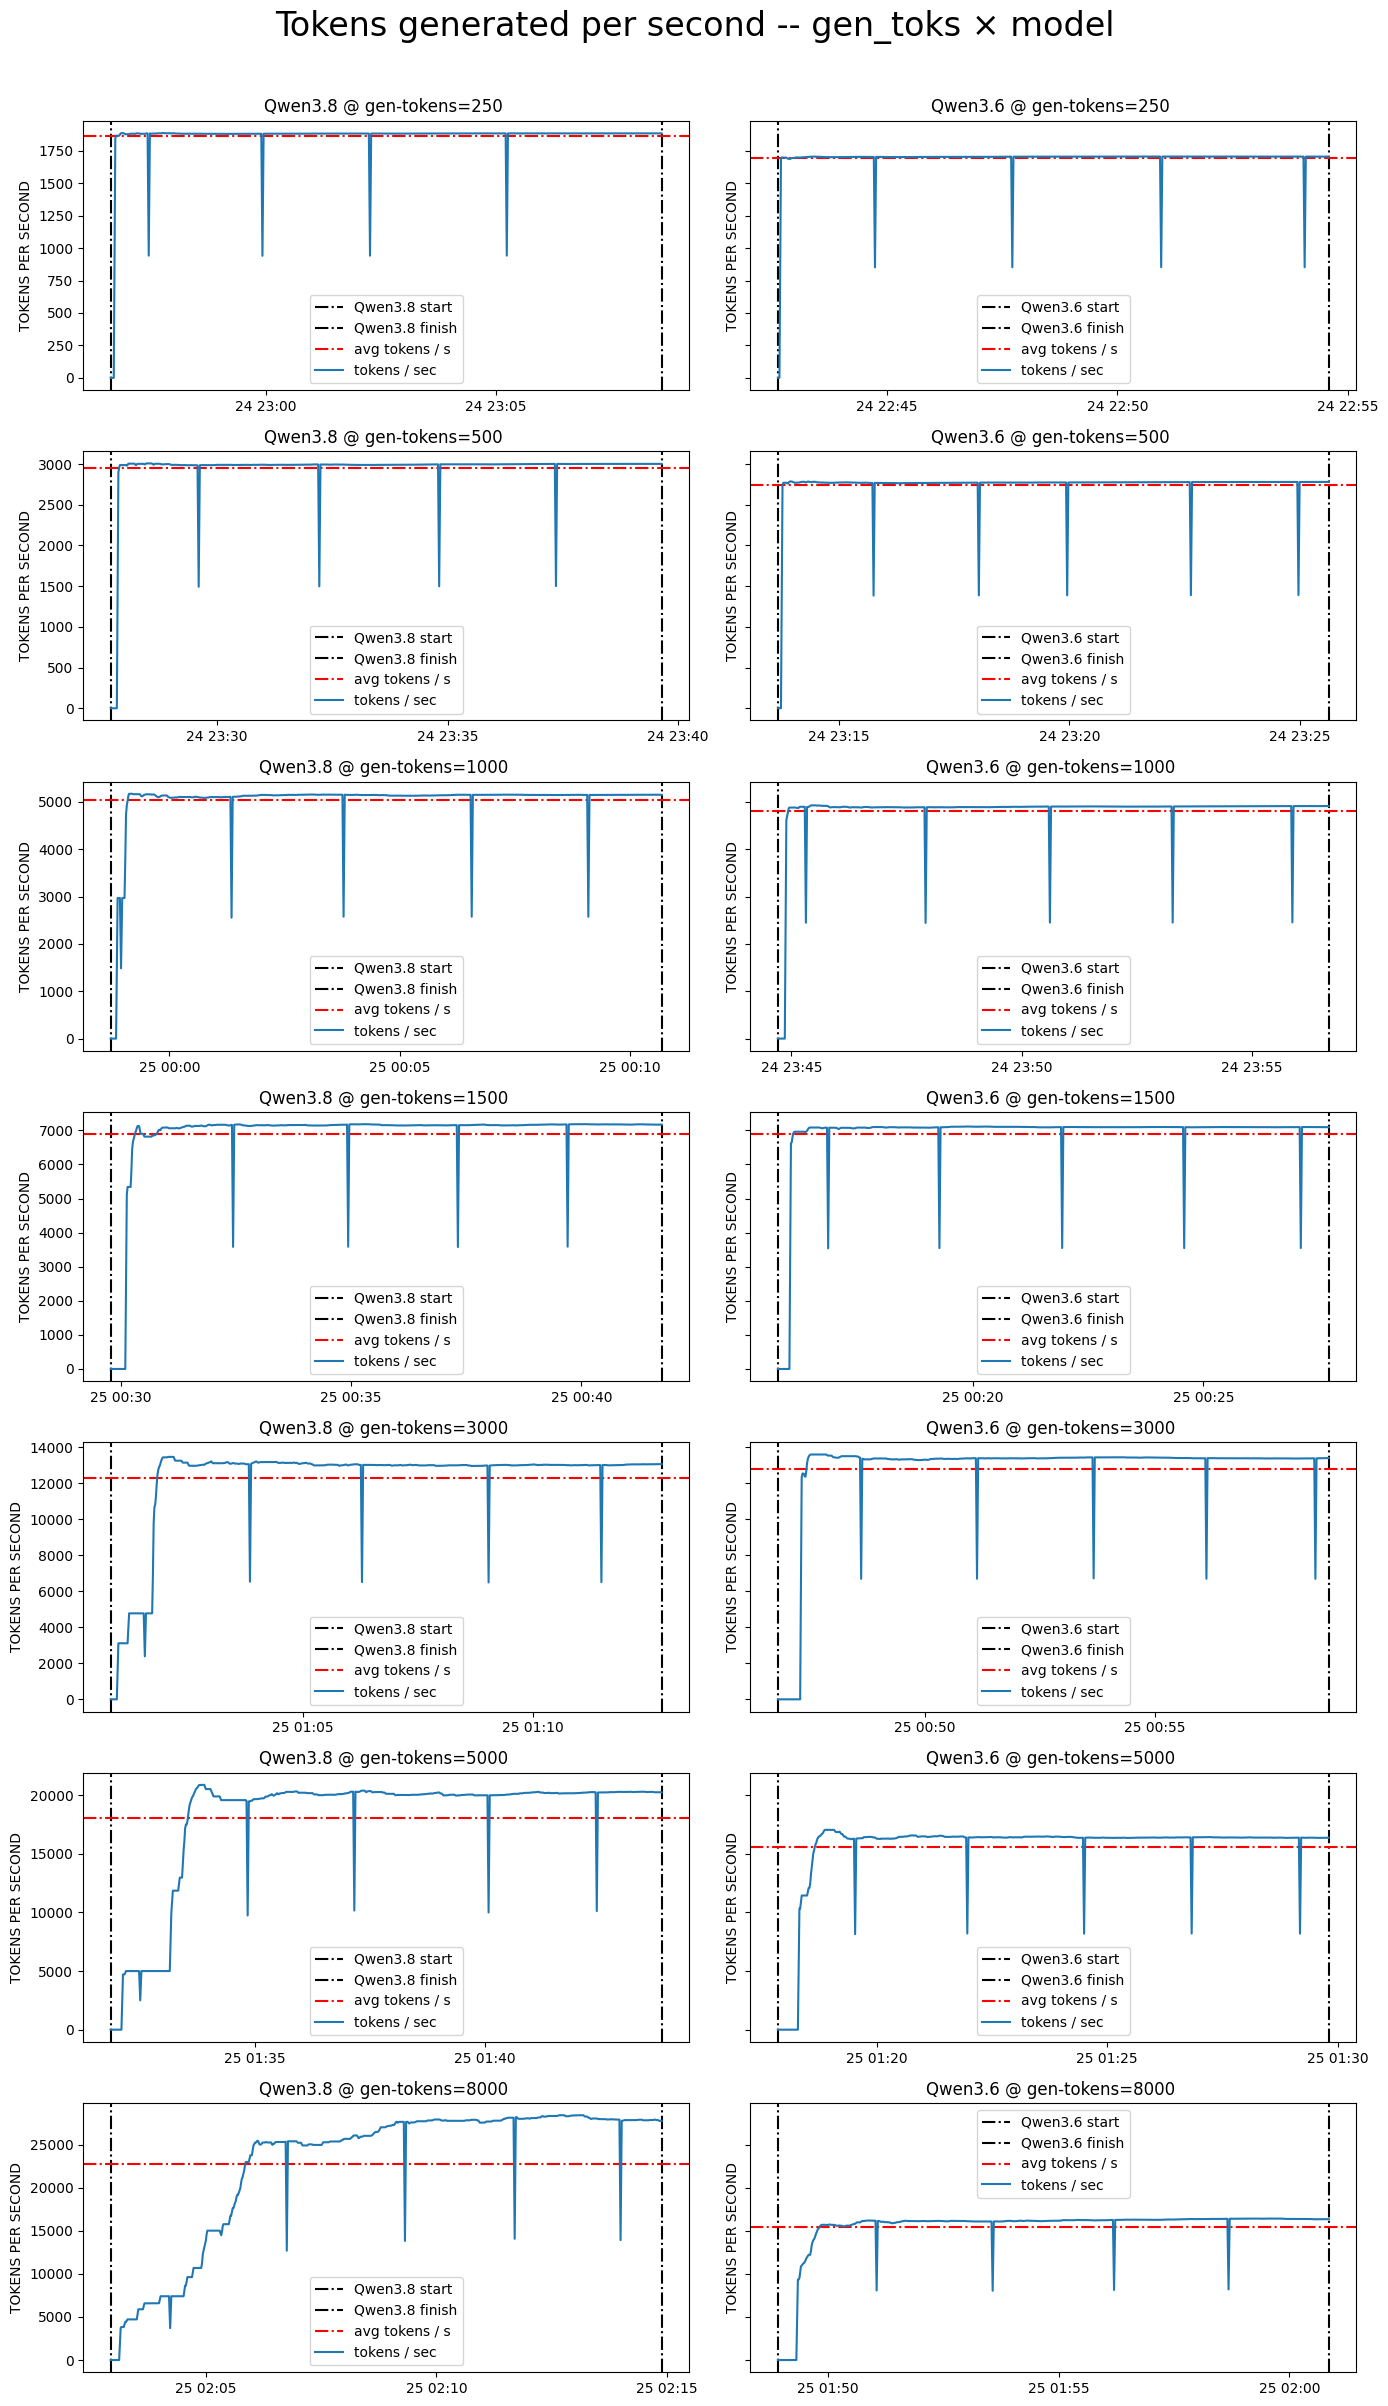

In [52]:
# --- setup grid ---
toks_list = sorted([int(x) for x in LCST[MODELS[0]].keys()])          # chiavi gen_toks (stesse per tutti)
toks_list = [str(x) for x in toks_list]
n_rows, n_cols = len(toks_list), len(MODELS)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(14, 3.5 * n_rows),
                         sharex=False,
                         sharey="row"
                        )

# flatten axes se n_rows == 1 (altrimenti 2D array)
if n_rows == 1:
    axes = [axes]

for r, toks in enumerate(GEN_TOKENS):
    for c, m in enumerate(MODELS):
        ax = axes[r][c] if n_rows > 1 else axes[c]
        df = LCST[m][toks]
        dts = df["Timestamp"][1:] - df["Timestamp"][:-1]
        tokens_per_sec = 0.5 * (df["Total Average Content Size"][1:] + df["Total Average Content Size"][:-1]) / dts
        centers = 0.5 * (df["Timestamp"][1:] + df["Timestamp"][:-1]) 
        centers = df.select(pl.from_epoch(centers, time_unit="s"))
        start, finish = centers[0], centers[-1]

        # Calculate on the whole process, TODO: maybe it's more relevant to skip the "activation-transient" ??
        avg_toks_s = tokens_per_sec.mean()
        RESULTS[m][toks]["avg_toks_s"] = avg_toks_s 
        
        ax.axvline(start, label=f"{m} start", color='black', ls="-.")
        ax.axvline(finish, label=f"{m} finish", color='black', ls="-.")
        ax.axhline(avg_toks_s, color="r", ls="-.", label="avg tokens / s")
        ax.plot(centers, tokens_per_sec, label="tokens / sec")
        ax.set_ylabel("TOKENS PER SECOND")
        ax.set_title(f"{m} @ gen-tokens={toks} ")
        ax.legend()
plt.suptitle("Tokens generated per second -- gen_toks × model", fontsize=24)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Active Gpu usage        [[ nvidia_smi.utilization_gpu ]]

97.90807799442896


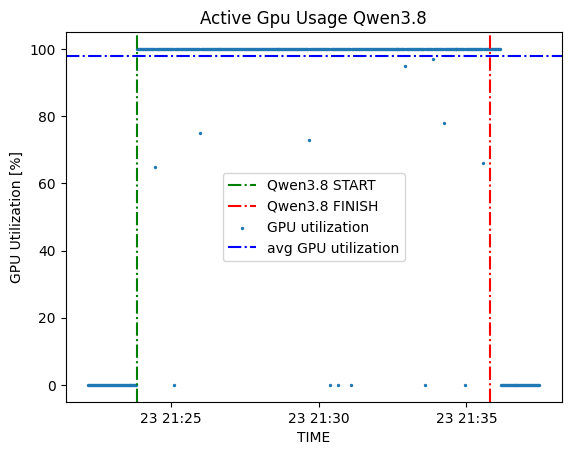

96.89136490250696


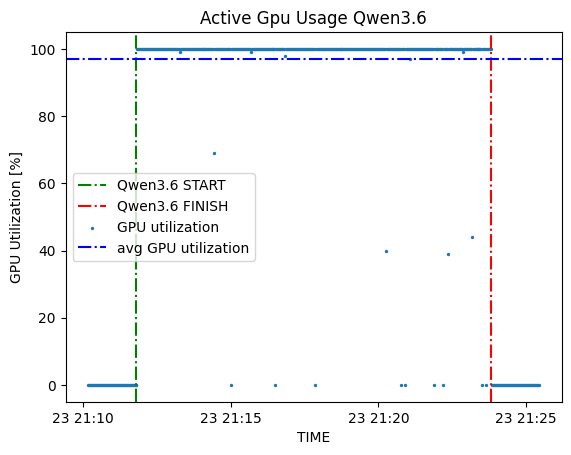

In [ ]:
for m in MODELS:
    plt.title(f"Active Gpu Usage {m}")
    gpu_index = RESULTS[m]["index_GPU"]
    proc = LCST[m]
    df = DB["nvidia_smi"]
    start, finish = min(proc["Timestamp"]), max(proc["Timestamp"])
    delta = 100 # Adding some pre and post process power usage data
    df = df.filter(pl.col("index") == gpu_index)
    df = df.filter(pl.col("Timestamp-us").is_between(start - delta, finish + delta, closed="none"))

    start_dt = datetime.fromtimestamp(start, timezone.utc)
    finish_dt = datetime.fromtimestamp(finish, timezone.utc)
    plt.axvline(start_dt, label=f"{m} START", color='green', ls="-.")
    plt.axvline(finish_dt, label=f"{m} FINISH", color='red', ls="-.")
    plt.scatter(df["timestamp"], df["utilization_gpu"], s=2.0, label="GPU utilization")

    df = df.filter(pl.col("Timestamp-us").is_between(start, finish, closed="none"))
    avg_gpu_utilization = df["utilization_gpu"].mean()
    RESULTS[m]["avg_gpu_utilization"] = avg_gpu_utilization

    plt.axhline(avg_gpu_utilization, color="b", ls="-.", label=f"avg GPU utilization")
    print(avg_gpu_utilization)
    plt.xlabel("TIME")
    plt.ylabel("GPU Utilization [%]")
    plt.legend()
    plt.show()
    

In [8]:
DB["nvidia_smi"]["utilization_gpu"]

utilization_gpu
i64
0
0
0
0
0
…
0
0
0


In [26]:
df["utilization_gpu"].mean()

78.75599128540306

>COMMENTS on RESULTS
> avg_power_at_GPU :    meglio isolare la stima dopo il transiente iniziale .
>       avg_toks_s :    meglio isolare la stima dopo il transiente .
>    avg_gpu_usage :    è fisso a 100% meno alcune misure a spot, realmente interessante? o più un check .
>

In [36]:
RESULTS

{'Qwen3.8': {'index_GPU': '5',
  'avg_power_at_GPU': 442.76231197771585,
  'avg_toks_s': 6364.429522266555,
  'avg_gpu_usage': shape: (1, 44)
  ┌──────┬──────────────┬──────┬───────┬───┬──────────────┬────────────┬──────────────┬──────────────┐
  │ arch ┆ compute_mode ┆ host ┆ index ┆ … ┆ encoder_stat ┆ power_draw ┆ timestamp    ┆ Timestamp-us │
  │ ---  ┆ ---          ┆ ---  ┆ ---   ┆   ┆ s_average_fp ┆ ---        ┆ ---          ┆ ---          │
  │ str  ┆ str          ┆ str  ┆ str   ┆   ┆ s            ┆ f64        ┆ datetime[μs] ┆ f64          │
  │      ┆              ┆      ┆       ┆   ┆ ---          ┆            ┆              ┆              │
  │      ┆              ┆      ┆       ┆   ┆ f64          ┆            ┆              ┆              │
  ╞══════╪══════════════╪══════╪═══════╪═══╪══════════════╪════════════╪══════════════╪══════════════╡
  │ null ┆ null         ┆ null ┆ null  ┆ … ┆ null         ┆ null       ┆ null         ┆ null         │
  └──────┴──────────────┴──────┴──